### This notebook thresholds the weights in the Ridge model according to the NNLS to see onlythe effect of high weights

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cortico_cereb_connectivity.summarize as ccs
import cortico_cereb_connectivity.globals as gl
import Functional_Fusion.atlas_map as am
import SUITPy as suit

/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/cuda/__init__.py:128: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11060). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
/home/UWO/ashahb7/Documents/cortico/lib/python3.8/site-packages/torch/__init__.py:955: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:432.)
  _C._set_default_tensor_type(t)


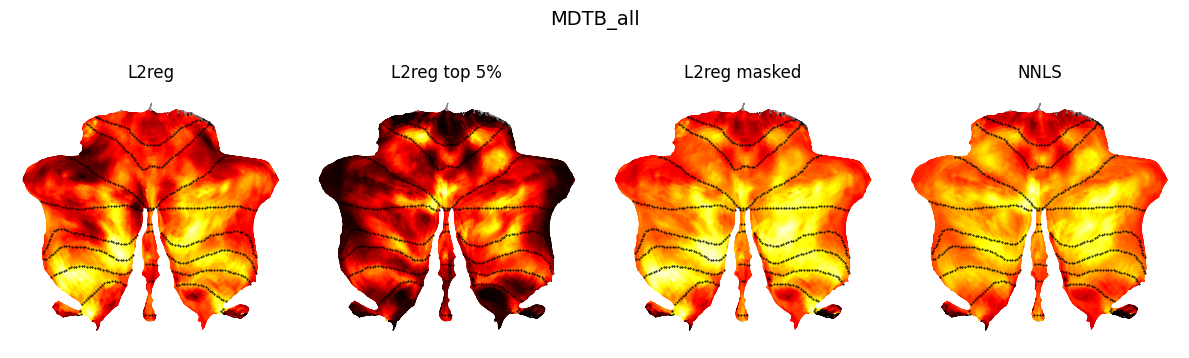

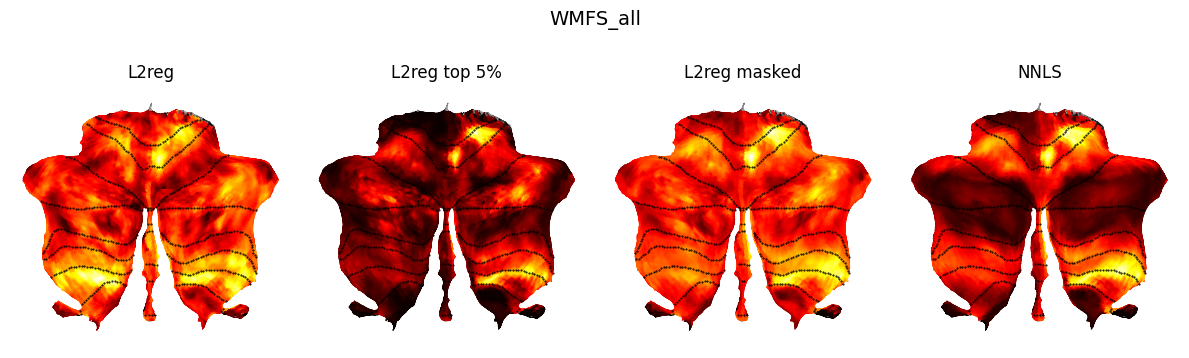

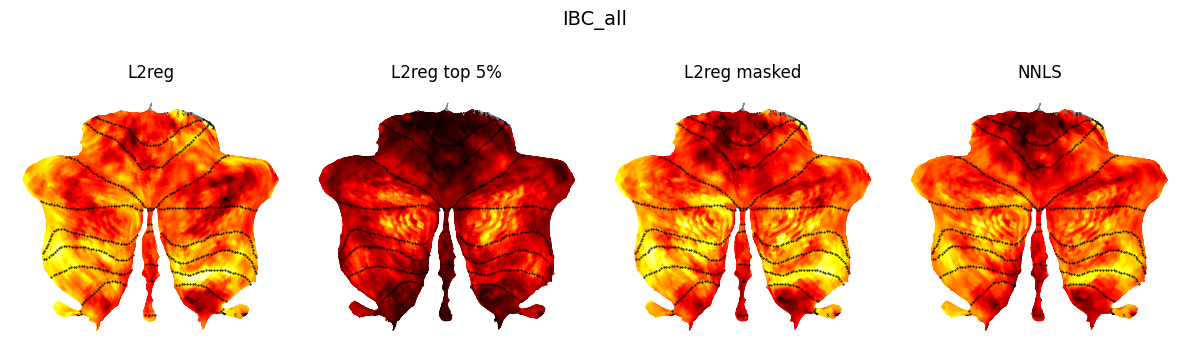

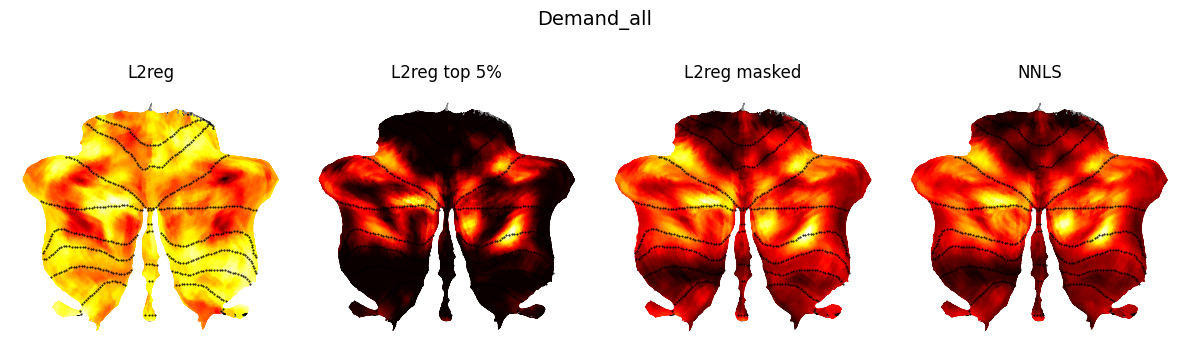

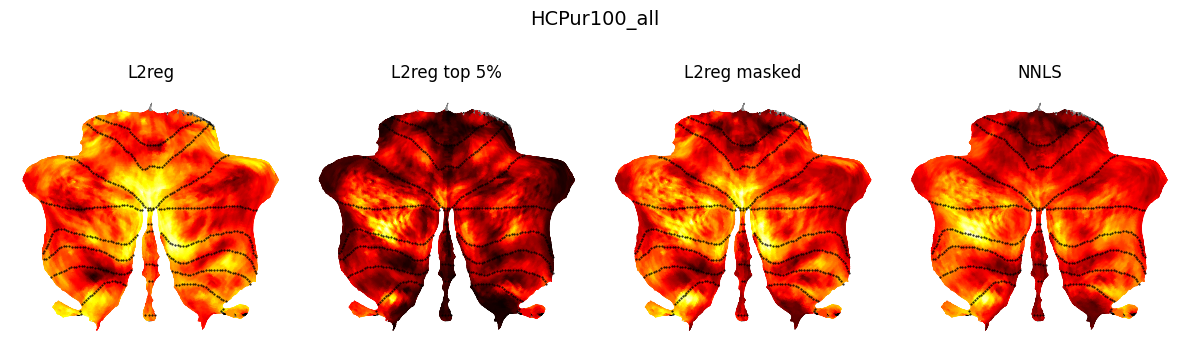

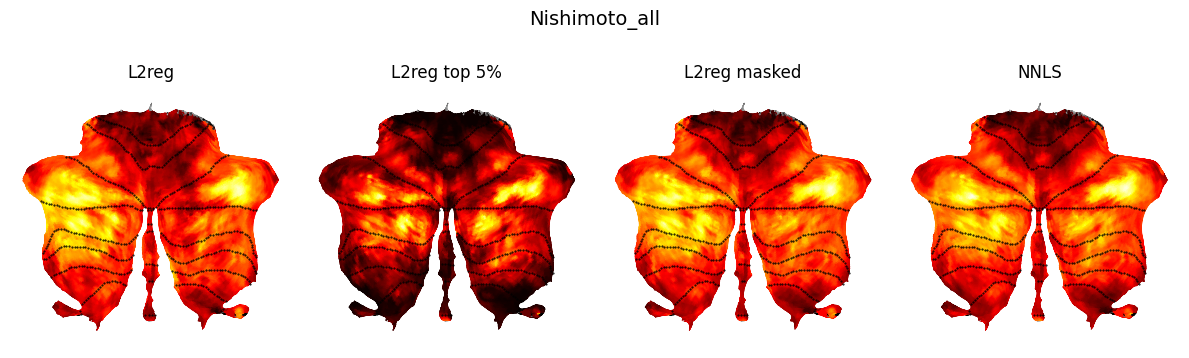

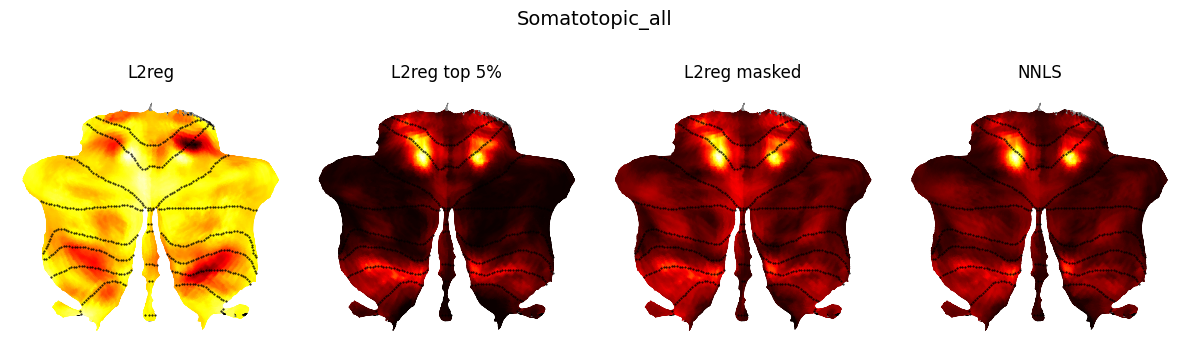

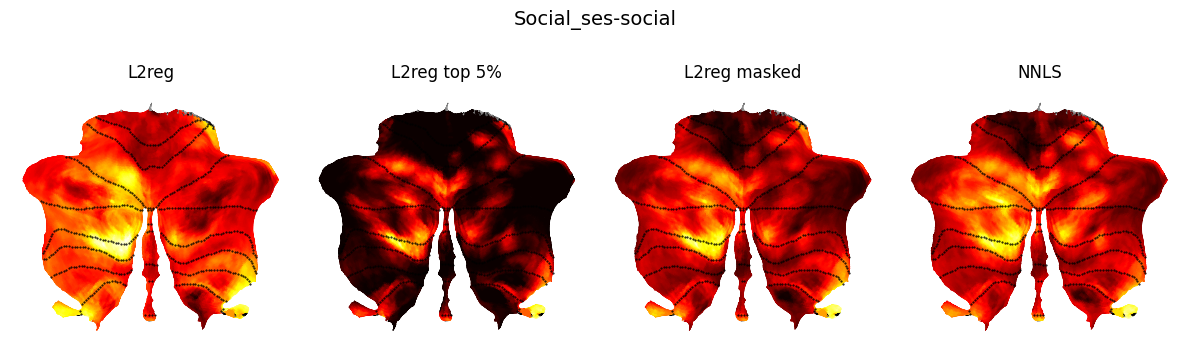

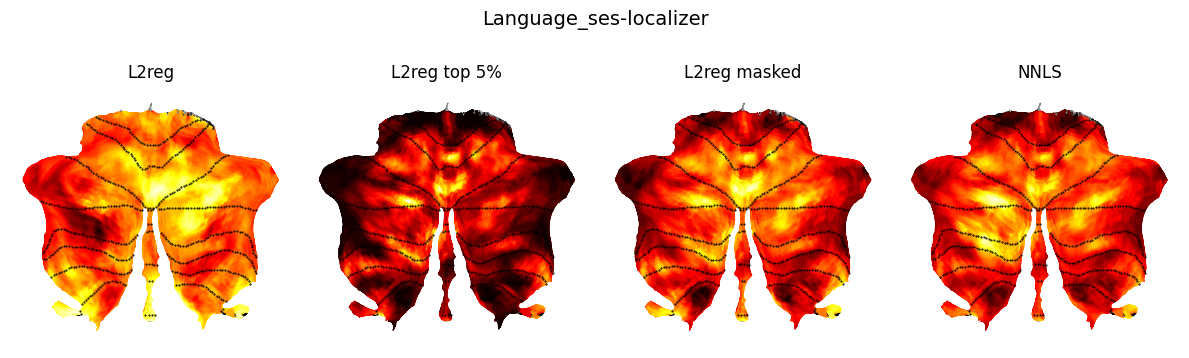

In [9]:
train_ds_list = [ds+"_"+ses for ds, ses in zip(gl.datasets, gl.sessions)]
extention_list_1 = ["A0", "A0", "A0", "A2", "A0", "A0", "A0", "A2", "A2"]
extention_list_2 = ["A6", "A6", "A6", "A6", "A2", "A8", "A8", "A8", "A6"]
atlas, _ = am.get_atlas('MNISymC3')
labels = ['L2reg', 'L2reg top 5%', 'L2reg masked', "NNLS"]

for t, (trainds, ext1, ext2) in enumerate(zip(train_ds_list, extention_list_1, extention_list_2)):
    # load model
    NNLS_mo, _ = ccs.get_model(trainds, 'Icosahedron1002', 'NNLS', ext1+"_group", cerebellum_atlas='MNISymC3')
    L2reg_mo, _ = ccs.get_model(trainds, 'Icosahedron1002', 'L2reg', ext2+"_group", cerebellum_atlas='MNISymC3')

    # mask the ridge
    L2reg_mask_coef = np.where(NNLS_mo.coef_ > 0, L2reg_mo.coef_, 0)
    thresh = np.percentile(L2reg_mo.coef_, 95)
    L2reg_high_coef = np.where(L2reg_mo.coef_ >= thresh, L2reg_mo.coef_, 0)

    # plot the weights
    plt.subplots(1, 4, figsize=(12, 3.5), tight_layout=True)
    plt.suptitle(f'{trainds}', y=1.01, fontsize=14)
    for i, W in enumerate([L2reg_mo.coef_, L2reg_high_coef, L2reg_mask_coef, NNLS_mo.coef_]):
        W_data = suit.vol_to_surf(atlas.data_to_nifti(np.mean(W, axis=1)), space='MNISymC')
        plt.subplot(1, 4, i+1)
        plt.title(labels[i])
        # max_weight = np.nanmax(np.abs(W_data))
        # suit.flatmap.plot(W_data, cmap='coolwarm', new_figure=False, bordersize=1, cscale=[-max_weight, max_weight])
        suit.flatmap.plot(W_data, cmap='hot', new_figure=False, bordersize=1)
    plt.show()

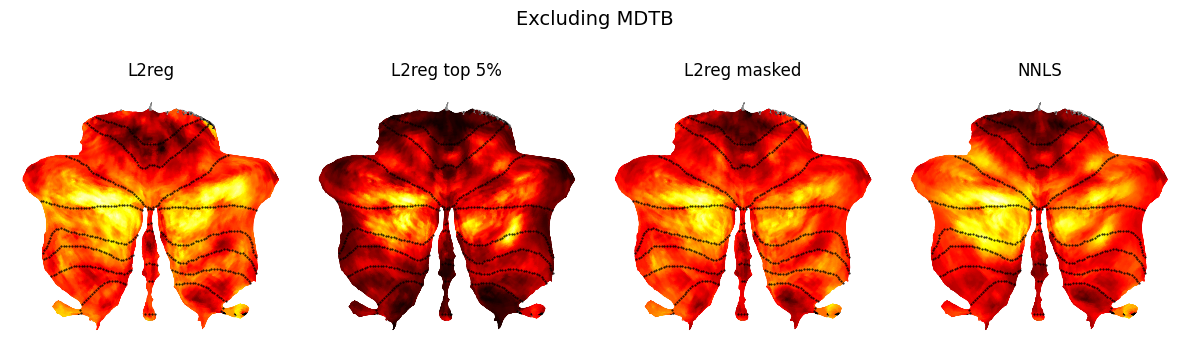

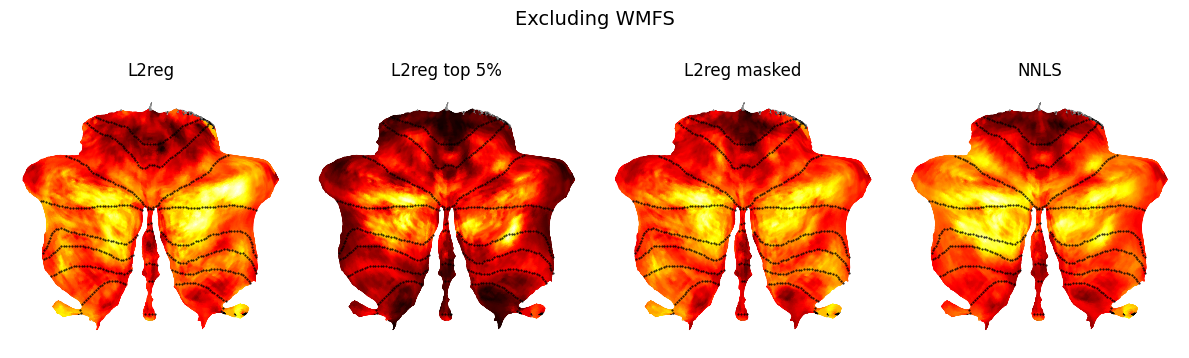

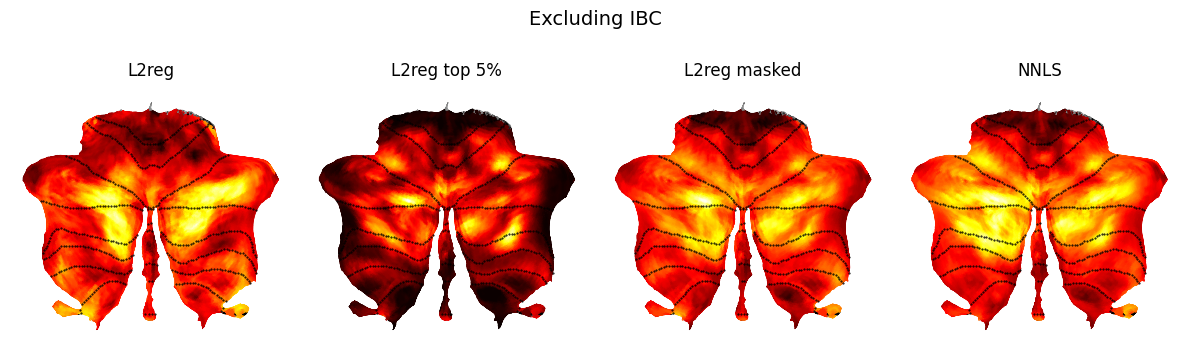

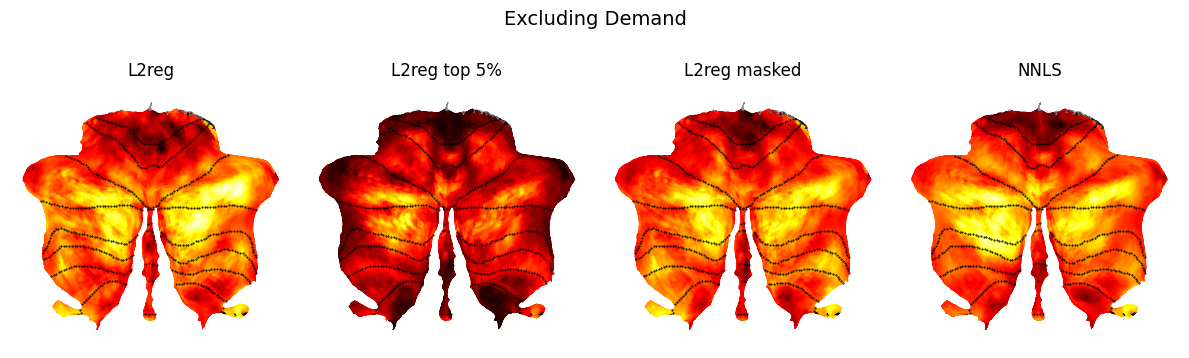

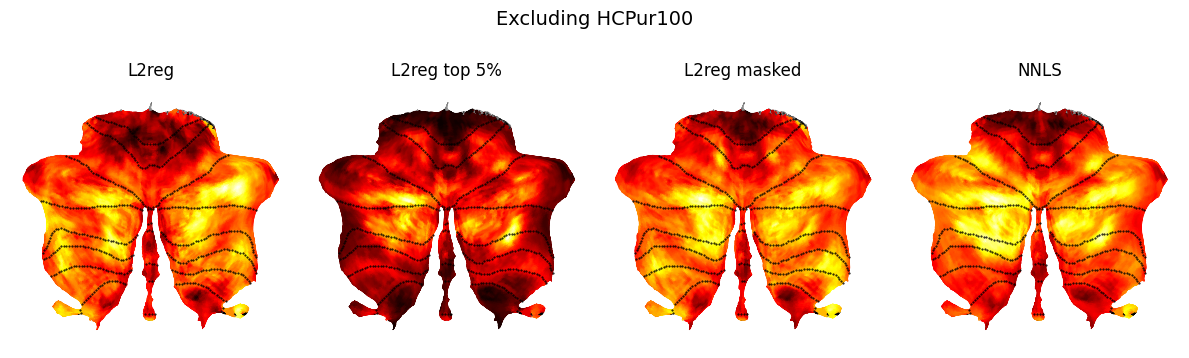

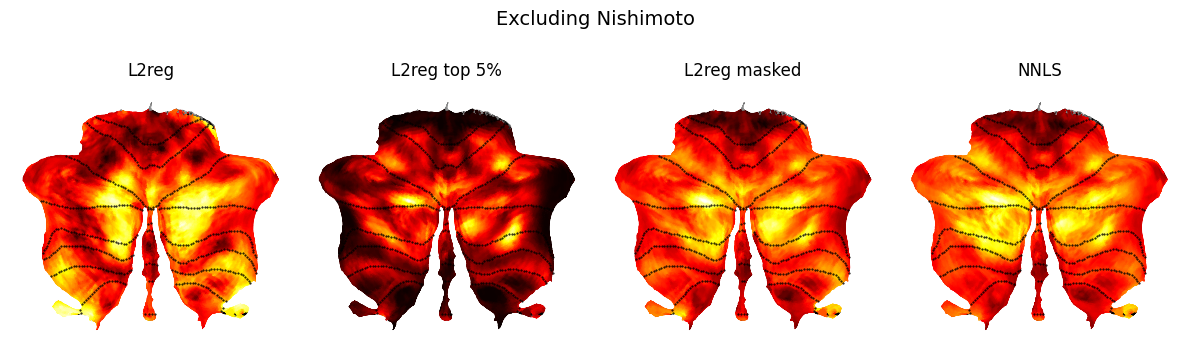

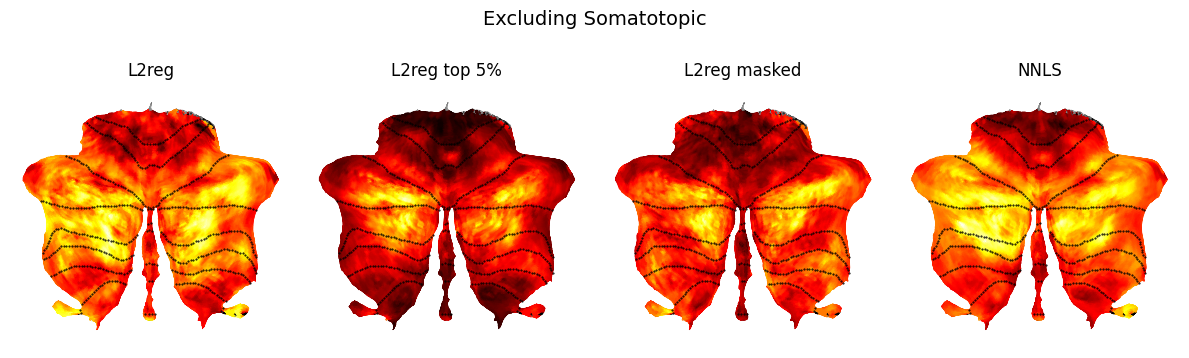

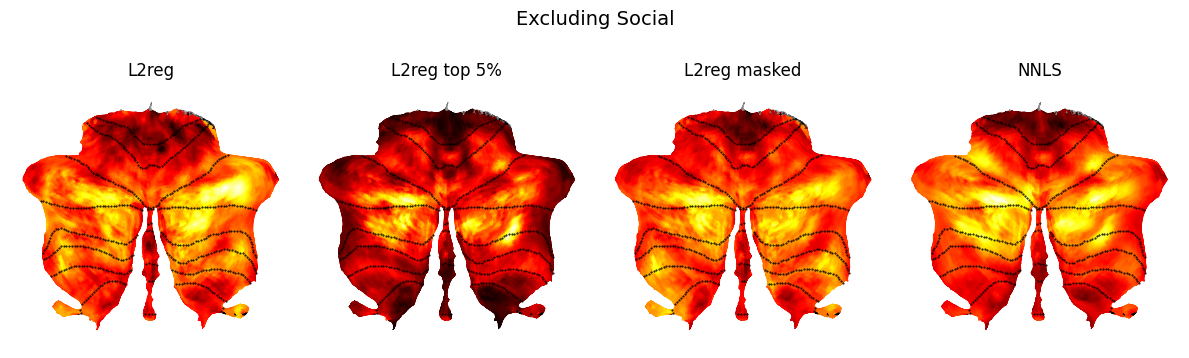

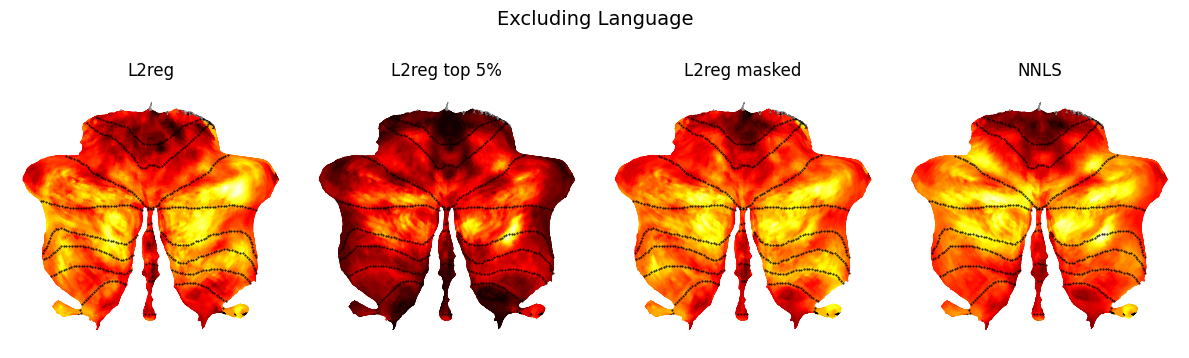

In [2]:
train_ds_list = gl.get_ldo_names()
eval_ds_list = gl.datasets
extention_list_1 = ["A1_global", "A0_global", "A1_global", "A1_global", "A0_global", "A1_global", "global", "A2_global", "A0_global"]
extention_list_2 = ["A2_global", "A2_global", "A4_global", "A2_global", "A2_global", "A4_global", "A0_global", "A2_global", "A2_global"]
atlas, _ = am.get_atlas('MNISymC3')
labels = ['L2reg', 'L2reg top 5%', 'L2reg masked', "NNLS"]

for t, (trainds, ext1, ext2, evds) in enumerate(zip(train_ds_list, extention_list_1, extention_list_2, eval_ds_list)):
    # load model
    NNLS_mo, _ = ccs.get_model(trainds, 'Icosahedron1002', 'NNLS', ext1, cerebellum_atlas='MNISymC3')
    L2reg_mo, _ = ccs.get_model(trainds, 'Icosahedron1002', 'L2reg', ext2, cerebellum_atlas='MNISymC3')

    # mask the ridge
    L2reg_mask_coef = np.where(NNLS_mo.coef_ > 0, L2reg_mo.coef_, 0)
    thresh = np.percentile(L2reg_mo.coef_, 95)
    L2reg_high_coef = np.where(L2reg_mo.coef_ >= thresh, L2reg_mo.coef_, 0)

    # plot the weights
    plt.subplots(1, 4, figsize=(12, 3.5), tight_layout=True)
    plt.suptitle(f'Excluding {evds}', y=1.01, fontsize=14)
    for i, W in enumerate([L2reg_mo.coef_, L2reg_high_coef, L2reg_mask_coef, NNLS_mo.coef_]):
        W_data = suit.vol_to_surf(atlas.data_to_nifti(np.mean(W, axis=1)), space='MNISymC')
        plt.subplot(1, 4, i+1)
        plt.title(labels[i])
        # max_weight = np.nanmax(np.abs(W_data))
        # suit.flatmap.plot(W_data, cmap='coolwarm', new_figure=False, bordersize=1, cscale=[-max_weight, max_weight])
        suit.flatmap.plot(W_data, cmap='hot', new_figure=False, bordersize=1)
    plt.show()